# Predictive Analytics with Walmart Stock Data

This notebook is a compact example of predictive analytics for a GitHub portfolio. It shows how to turn historical stock data into short-term forecasts using simple, interpretable methods.

The workflow includes:
- preparing time-series data
- comparing forecasting methods

## Forecasting methods

The notebook compares four lightweight approaches for a 10-day forecast horizon:
1. 30-day moving average
2. 5-day weighted moving average
3. exponential smoothing
4. linear regression trend

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from sklearn.linear_model import LinearRegression

##### Read and prep data

In [3]:
walmart_df = pd.read_csv("WalMartStock.csv")
walmart_df['Date'] = pd.to_datetime(walmart_df['Date'])
walmart_df.set_index('Date', inplace=True)
#walmart_df.index.freq = 'B'
walmart_df_series = walmart_df['Close']

C:\Users\Ben Sylve\AppData\Local\Temp\ipykernel_3420\4166672568.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  walmart_df['Date'] = pd.to_datetime(walmart_df['Date'])


In [4]:
walmart_df_future_dates = pd.bdate_range(start=walmart_df_series.index[-1] + pd.offsets.BDay(1), periods=10)

##### 30-Day Moving Average

In [5]:
walmart_moving_avg_30 = walmart_df_series.rolling(window=30).mean()

walmart_moving_avg_future = []
walmart_df_series_extended = walmart_df_series.copy()

for _ in range(10):
    next_value = walmart_df_series_extended[-30:].mean()
    walmart_moving_avg_future.append(next_value)
    walmart_df_series_extended = pd.concat([walmart_df_series_extended, pd.Series([next_value], index=[walmart_df_series_extended.index[-1] + pd.offsets.BDay(1)])])

for i, prediction in enumerate(walmart_moving_avg_future, 1):
    print(f"Day {i} prediction: {prediction:.2f}")

Day 1 prediction: 57.78
Day 2 prediction: 57.84
Day 3 prediction: 57.84
Day 4 prediction: 57.87
Day 5 prediction: 57.86
Day 6 prediction: 57.84
Day 7 prediction: 57.82
Day 8 prediction: 57.83
Day 9 prediction: 57.83
Day 10 prediction: 57.82


##### 5-Day Weighted Moving Average

In [6]:
# 5-Day Weighted Moving Average without lambda function
weights = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
def weighted_moving_average(series, window, weights):
    result = []
    for i in range(len(series)):
        if i + 1 < window:
            result.append(np.nan)
        else:
            weighted_sum = 0
            for j in range(window):
                weighted_sum += series.iloc[i - j] * weights[j]
            result.append(weighted_sum)
    return pd.Series(result, index=series.index)

walmart_weighted_moving_avg_5 = weighted_moving_average(walmart_df_series, 5, weights)

# Forecast next 10 days
walmart_weighted_future = []
walmart_df_series_extended_wma = walmart_df_series.copy()

for _ in range(10):
    last_5 = walmart_df_series_extended_wma[-5:].values
    next_value = np.sum(last_5[::-1] * weights)
    walmart_weighted_future.append(next_value)
    walmart_df_series_extended_wma = pd.concat([walmart_df_series_extended_wma, pd.Series([next_value], index=[walmart_df_series_extended_wma.index[-1] + pd.offsets.BDay(1)])])

for i, prediction in enumerate(walmart_weighted_future, 1):
    print(f"Day {i} weighted prediction: {prediction:.2f}")

Day 1 weighted prediction: 59.10
Day 2 weighted prediction: 59.21
Day 3 weighted prediction: 59.23
Day 4 weighted prediction: 59.18
Day 5 weighted prediction: 59.16
Day 6 weighted prediction: 59.17
Day 7 weighted prediction: 59.18
Day 8 weighted prediction: 59.18
Day 9 weighted prediction: 59.18
Day 10 weighted prediction: 59.18


In [7]:
walmart_weighted_moving_avg_5

Date
2001-02-05       NaN
2001-02-06       NaN
2001-02-07       NaN
2001-02-08       NaN
2001-02-09    52.020
               ...  
2002-01-29    58.546
2002-01-30    58.943
2002-01-31    59.411
2002-02-01    59.327
2002-02-04    59.102
Length: 248, dtype: float64

##### Exponential Smoothing

##### 0.3

In [8]:
# Exponential Smoothing with smoothing constant 0.3 using Holt
exp_smoothing_0_3_model = Holt(walmart_df_series, initialization_method="estimated").fit(smoothing_level=0.3)
exp_smoothing_0_3 = exp_smoothing_0_3_model.fittedvalues
exp_smoothing_0_3_future = exp_smoothing_0_3_model.forecast(10)

for i, prediction in enumerate(exp_smoothing_0_3_future, 1):
    print(f"Day {i} exponential smoothing prediction: {prediction:.2f}")

Day 1 exponential smoothing prediction: 59.86
Day 2 exponential smoothing prediction: 60.05
Day 3 exponential smoothing prediction: 60.24
Day 4 exponential smoothing prediction: 60.43
Day 5 exponential smoothing prediction: 60.62
Day 6 exponential smoothing prediction: 60.80
Day 7 exponential smoothing prediction: 60.99
Day 8 exponential smoothing prediction: 61.18
Day 9 exponential smoothing prediction: 61.37
Day 10 exponential smoothing prediction: 61.56


C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


##### 0.8

In [9]:
# Exponential Smoothing with smoothing constant 0.8
exp_smoothing_0_8_model = Holt(walmart_df_series, initialization_method="estimated").fit(smoothing_level=0.8)
exp_smoothing_0_8 = exp_smoothing_0_8_model.fittedvalues
exp_smoothing_0_8_future = exp_smoothing_0_8_model.forecast(10)

for i, prediction in enumerate(exp_smoothing_0_8_future, 1):
    print(f"Day {i} exponential smoothing prediction: {prediction:.2f}")

Day 1 exponential smoothing prediction: 59.02
Day 2 exponential smoothing prediction: 59.04
Day 3 exponential smoothing prediction: 59.07
Day 4 exponential smoothing prediction: 59.09
Day 5 exponential smoothing prediction: 59.11
Day 6 exponential smoothing prediction: 59.13
Day 7 exponential smoothing prediction: 59.15
Day 8 exponential smoothing prediction: 59.17
Day 9 exponential smoothing prediction: 59.19
Day 10 exponential smoothing prediction: 59.21


C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Ben Sylve\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
exp_smoothing_0_8

Date
2001-02-05    53.744162
2001-02-06    53.842117
2001-02-07    53.349709
2001-02-08    54.419227
2001-02-09    52.745130
                ...    
2002-01-29    58.659453
2002-01-30    58.081176
2002-01-31    59.437520
2002-02-01    59.892789
2002-02-04    59.407843
Length: 248, dtype: float64

##### Linear Regression

In [11]:
# Simple Linear Regression
days = np.arange(len(walmart_df_series)).reshape(-1, 1)
reg_model = LinearRegression().fit(days, walmart_df_series)
future_days = np.arange(len(walmart_df_series), len(walmart_df_series) + 10).reshape(-1, 1)
linear_regression = reg_model.predict(days)
linear_regression_future = reg_model.predict(future_days)

for i, prediction in enumerate(linear_regression_future, 1):
    print(f"Day {i} linear regression prediction: {prediction:.2f}")

Day 1 linear regression prediction: 55.66
Day 2 linear regression prediction: 55.69
Day 3 linear regression prediction: 55.71
Day 4 linear regression prediction: 55.74
Day 5 linear regression prediction: 55.77
Day 6 linear regression prediction: 55.79
Day 7 linear regression prediction: 55.82
Day 8 linear regression prediction: 55.85
Day 9 linear regression prediction: 55.87
Day 10 linear regression prediction: 55.90


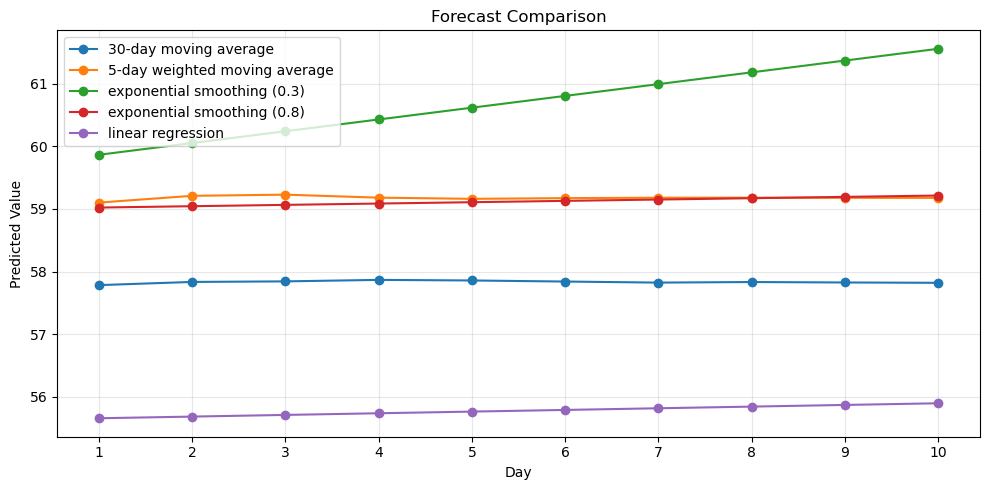

In [12]:
import matplotlib.pyplot as plt

# Example: combine your forecast lists into a simple dictionary
# Replace these with your actual forecast variables
forecasts = {
    "30-day moving average": walmart_moving_avg_future,
    "5-day weighted moving average": walmart_weighted_future,
    "exponential smoothing (0.3)": list(exp_smoothing_0_3_future),
    "exponential smoothing (0.8)": list(exp_smoothing_0_8_future),
    "linear regression": list(linear_regression_future),
}

# Create x-axis for forecast horizon
forecast_horizon = list(range(1, len(next(iter(forecasts.values()))) + 1))

plt.figure(figsize=(10, 5))
for name, values in forecasts.items():
    plt.plot(forecast_horizon, values, marker="o", label=name)

plt.title("Forecast Comparison")
plt.xlabel("Day")
plt.ylabel("Predicted Value")
plt.xticks(forecast_horizon)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()